# Assignment 4 — How Few Components Can You Get Away With?

**Course:** Feature Engineering & MLOps  
**Assignment:** 4  
**Topic:** Dimensionality Reduction (PCA Practical)

### Objective
Find the **smallest number of principal components** that lets Linear Regression achieve roughly the **same test accuracy** as using all 60 raw features, and justify the choice using explained variance, a scree plot, cumulative explained variance, and held-out test R².


# Assignment 4 — Requirements & Completion Checklist

> Based directly on the Assignment 4 PDF. The notebook below contains the required markdown sections, code, tables, charts, and executed outputs.

## Required tasks
- [x] Load `pca_regression_data.csv` and use the 60 columns `feature_1` through `feature_60` with `score` as the continuous target.
- [x] Split data into 75% training / 25% test using a fixed `random_state`.
- [x] Standardize all 60 features with the scaler fitted on training data only.
- [x] Train Linear Regression using all 60 standardized features and report held-out test R².
- [x] Fit unrestricted PCA on the standardized training features.
- [x] Produce a scree plot for at least the first 20 components.
- [x] Produce a separate cumulative explained-variance plot with a 95% horizontal reference line.
- [x] Record a visual scree-plot elbow estimate before using the regression comparison.
- [x] Evaluate PCA component counts: 2, 4, 6, 8, 10, 12, 15, 20, 30, 40.
- [x] For each component count, fit PCA on training data, transform train/test, train a fresh Linear Regression, and record test R².
- [x] Plot test R² versus number of PCA components with the full-feature baseline R² reference line.
- [x] Select the smallest component count whose R² is within 0.01 of the baseline or higher.
- [x] Compare the empirical component count with the visual scree-plot elbow.
- [x] Provide a 4–6 sentence explanation using the actual results and latent-factor/redundancy reasoning.
- [x] Optional bonus: repeat the comparison with `RandomForestRegressor` and explain any difference.

## Submission requirements
- [x] Notebook filename: `Assignment4_PCA_Components.ipynb`
- [x] Clear markdown headers matching Sections 4.1–4.4.
- [x] Outputs retained, including all 3 required charts.
- [ ] Commit under the repository's top-level `Assignments` folder.
- [ ] Run top-to-bottom in the target repository environment and push to GitHub.
- [ ] Share the GitHub repository link with the instructor.

## Observed result
- Baseline Linear Regression test R²: **0.858373**
- Smallest acceptable PCA count: **8**
- R² with 8 components: **0.871584**
- Visual elbow estimate: **~8**


## Dataset Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor

print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
from pathlib import Path

candidate_paths = [
    Path("data/raw/pca_regression_data.csv"),
    Path("../data/raw/pca_regression_data.csv"),
    Path("pca_regression_data.csv"),
    Path("/mnt/data/pca_regression_data.csv"),
]
DATA_PATH = next((p for p in candidate_paths if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("pca_regression_data.csv not found.")
df = pd.read_csv(DATA_PATH)

feature_cols = [f"feature_{i}" for i in range(1, 61)]
X = df[feature_cols]
y = df["score"]

print("Dataset path:", DATA_PATH)
print("Dataset shape:", df.shape)
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
df.head()


Dataset path: data/raw/pca_regression_data.csv
Dataset shape: (800, 62)
Feature matrix shape: (800, 60)
Target shape: (800,)


,student_id,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37,feature_38,feature_39,feature_40,feature_41,feature_42,feature_43,feature_44,feature_45,feature_46,feature_47,feature_48,feature_49,feature_50,feature_51,feature_52,feature_53,feature_54,feature_55,feature_56,feature_57,feature_58,feature_59,feature_60,score
0,1,1.006103,2.625090,-0.021036,6.231392,3.147998,-0.044665,-3.420442,1.567874,0.189118,-2.626625,-1.304814,-2.542264,1.805347,-0.141981,-3.014586,-2.265383,-1.640502,0.418101,2.502967,-3.145750,0.650914,0.267328,-0.188936,-3.296713,0.498072,-0.642767,1.160147,1.106437,0.700787,-0.147699,-2.838052,1.134797,2.802358,0.537837,1.240140,-1.087054,0.487976,2.932443,-1.399364,-0.013645,0.398901,-0.035275,0.387914,-0.496947,5.666176,1.284620,-3.442413,1.355089,1.069439,-1.932360,-0.868302,3.515794,-1.345712,1.038361,1.358821,4.510162,-0.345406,3.255827,0.607355,1.126482,-0.319225
1,2,4.442871,-2.006560,-1.181818,1.695413,-3.168459,-5.989658,-2.662836,-4.174475,-2.323000,4.380456,2.872838,0.471688,-3.497984,1.505252,1.396832,-2.823093,-2.398480,3.280243,-5.847437,-2.723355,-3.265934,-3.864886,4.233313,-2.638532,-2.872768,2.595349,-0.169384,-0.346149,7.121322,-2.411343,1.364411,3.189065,0.091755,0.556482,-1.774184,-1.814985,2.534461,-3.895198,-0.417048,-0.478407,-0.949090,1.995306,0.320669,3.699394,0.291946,-2.137657,6.029133,1.870992,2.665392,-0.306679,4.140025,1.640106,4.207556,-3.367389,1.398171,1.162581,0.681762,-4.742943,2.150911,-5.587529,3.418536
2,3,1.723720,-3.352754,1.020613,0.533918,3.769766,-0.004683,-0.019345,0.515542,-0.225922,-0.414232,0.383296,-0.155779,4.246810,1.192809,-0.402501,0.735668,-2.861297,3.101858,-0.710064,2.716005,-0.760852,-0.533589,-3.868551,-0.496538,1.045011,0.123755,-1.493125,3.001906,0.670960,-0.554189,-1.014735,0.038448,0.806473,1.158614,-2.725631,0.739283,3.430628,3.133591,-0.170556,-0.766203,1.510806,1.822660,1.570117,3.139087,0.059343,-1.882664,1.103726,1.937708,-1.248620,1.248438,5.614804,0.874327,-0.868329,1.769608,-1.165895,1.189553,3.324718,-1.858829,2.980939,1.121997,2.618471
3,4,0.411140,2.025221,-2.621914,-5.890728,-1.068567,3.413866,3.243600,4.476142,2.650463,-1.791848,1.083980,0.083042,-1.551795,-1.588513,1.556235,-0.472898,-2.309321,0.206320,2.627099,0.496784,0.886819,3.112425,-1.590987,1.784715,4.551132,-3.195578,-1.553017,0.251549,0.022868,2.328113,2.809417,-2.678859,3.348200,-1.482855,0.210397,3.001572,-1.943925,-0.417986,-5.818844,0.526919,0.153595,-1.584687,-1.181060,-2.776797,-2.433931,-2.019183,-1.010900,6.486531,-2.511694,1.374522,-0.545801,-0.967199,-1.848642,1.535045,-4.300282,-5.457053,1.066226,2.996332,4.766362,1.312600,-3.740992
4,5,1.011855,3.029584,-2.574027,-1.983156,-1.696483,-2.258118,-1.735768,0.689373,-0.849770,0.147247,0.495655,1.018668,-3.364813,0.857498,-1.483207,0.505665,-1.168776,-1.828997,0.558257,-1.601015,-0.536534,0.115269,0.086054,0.750257,1.704789,-0.049982,-0.142451,0.543119,-0.943882,-1.249571,-1.947715,-0.102637,3.072289,1.424738,-1.226095,-2.550533,-3.070282,-1.546594,-1.082614,0.080874,-0.992874,-1.045934,-0.309045,-0.817560,-0.039599,2.019017,0.313624,-3.371910,0.506465,-0.972583,-1.280074,-1.185252,-0.883210,0.022223,-1.336599,2.028197,-2.490620,1.414216,-1.392051,0.611356,1.294747


## 4.1 — Baseline: all 60 raw features

1. Split into train (75%) and test (25%) using a fixed `random_state`.
2. Standardize the 60 features, fitting the scaler on train only.
3. Train Linear Regression on all 60 standardized features.
4. Report test R².

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

baseline_model = LinearRegression()
baseline_model.fit(X_train_scaled, y_train)
baseline_r2 = r2_score(y_test, baseline_model.predict(X_test_scaled))

print(f"Baseline test R²: {baseline_r2:.6f}")


Baseline test R²: 0.858373


### Baseline Result

The all-60-feature Linear Regression baseline achieved **test R² = 0.858373**.

## 4.2 — PCA: explained variance and the scree plot

1. Fit unrestricted PCA on standardized **training** features.
2. Plot explained variance ratio against component number for at least the first 20 components.
3. Plot cumulative explained variance separately with a horizontal 95% reference line.
4. From the scree plot alone, record a visual elbow estimate **before** model comparison.

In [4]:
pca_full = PCA()
X_train_pca = pca_full.fit_transform(X_train_scaled)

explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

variance_table = pd.DataFrame({
    "component": np.arange(1, len(explained_variance_ratio)+1),
    "explained_variance_ratio": explained_variance_ratio,
    "cumulative_explained_variance": cumulative_explained_variance
})
variance_table.head(20)


,component,explained_variance_ratio,cumulative_explained_variance
0,1,0.212700,0.212700
1,2,0.180426,0.393125
2,3,0.136387,0.529512
3,4,0.126337,0.655849
4,5,0.115100,0.770949
5,6,0.090079,0.861028
6,7,0.073817,0.934845
7,8,0.053718,0.988563
8,9,0.000605,0.989168
9,10,0.000504,0.989672


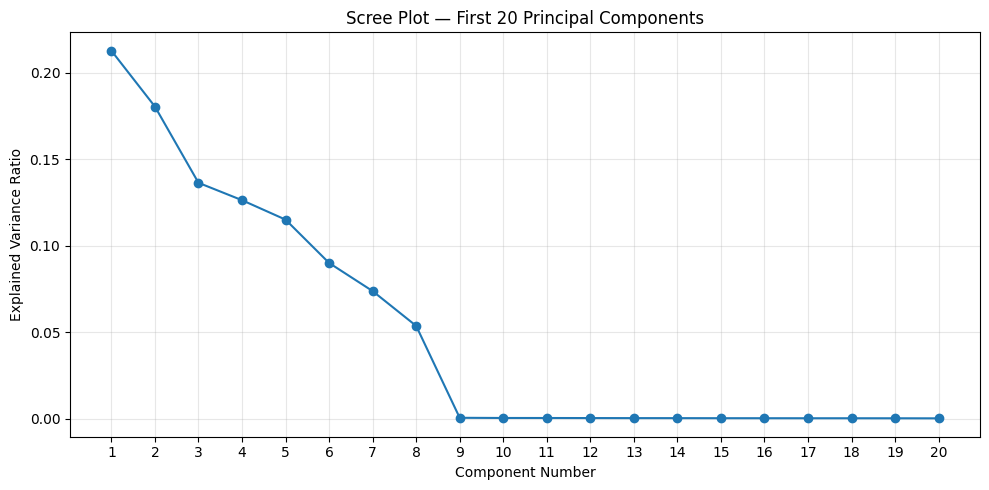

In [5]:
plt.figure(figsize=(10,5))
plt.plot(range(1,21), explained_variance_ratio[:20], marker="o")
plt.xlabel("Component Number")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot — First 20 Principal Components")
plt.xticks(range(1,21))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


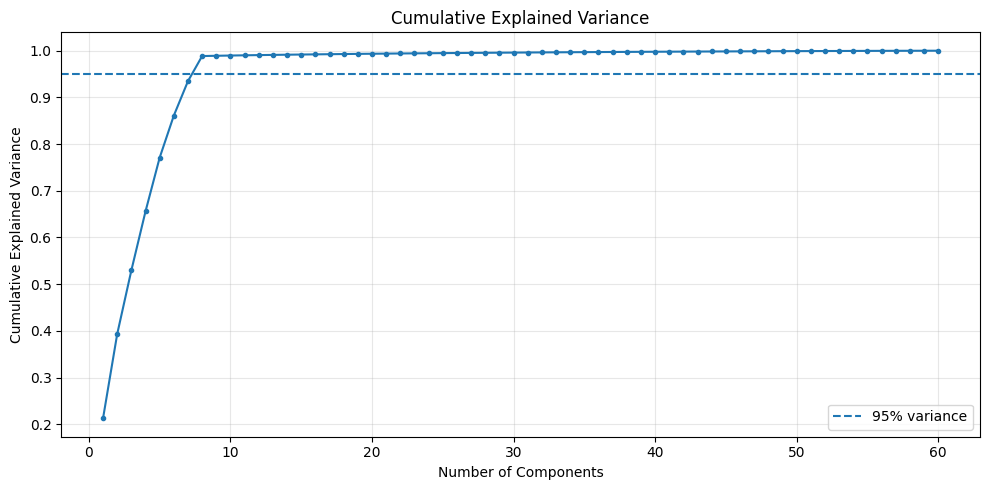

In [6]:
plt.figure(figsize=(10,5))
plt.plot(range(1,len(cumulative_explained_variance)+1),
         cumulative_explained_variance, marker="o", markersize=3)
plt.axhline(0.95, linestyle="--", label="95% variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Visual Scree-Plot Estimate

**Visual elbow estimate: approximately 8 components.**

This estimate is made from the scree plot before considering the regression results. The cumulative explained variance reaches **95% at component 8**, reinforcing the indication that the effective dimensionality is much smaller than 60.

## 4.3 — Find the smallest component count that matches baseline accuracy

Required component counts:

`[2, 4, 6, 8, 10, 12, 15, 20, 30, 40]`

For each count, fit PCA on training data, transform train and test data, train a fresh Linear Regression model, and record test R².

The selected count must have R² **within 0.01 of the baseline or higher**.

In [7]:
component_counts = [2,4,6,8,10,12,15,20,30,40]
results = []

for n in component_counts:
    pca_n = PCA(n_components=n)
    Xtr_n = pca_n.fit_transform(X_train_scaled)
    Xte_n = pca_n.transform(X_test_scaled)

    model = LinearRegression()
    model.fit(Xtr_n, y_train)
    test_r2 = r2_score(y_test, model.predict(Xte_n))

    results.append({
        "components": n,
        "test_r2": test_r2,
        "difference_from_baseline": test_r2 - baseline_r2,
        "within_0.01_or_better": test_r2 >= baseline_r2 - 0.01
    })

results_df = pd.DataFrame(results)
results_df


,components,test_r2,difference_from_baseline,within_0.01_or_better
0,2,0.240924,-0.617449,False
1,4,0.498896,-0.359477,False
2,6,0.694589,-0.163784,False
3,8,0.871584,0.013211,True
4,10,0.872236,0.013863,True
5,12,0.871817,0.013444,True
6,15,0.872381,0.014008,True
7,20,0.872546,0.014172,True
8,30,0.866501,0.008128,True
9,40,0.863369,0.004995,True


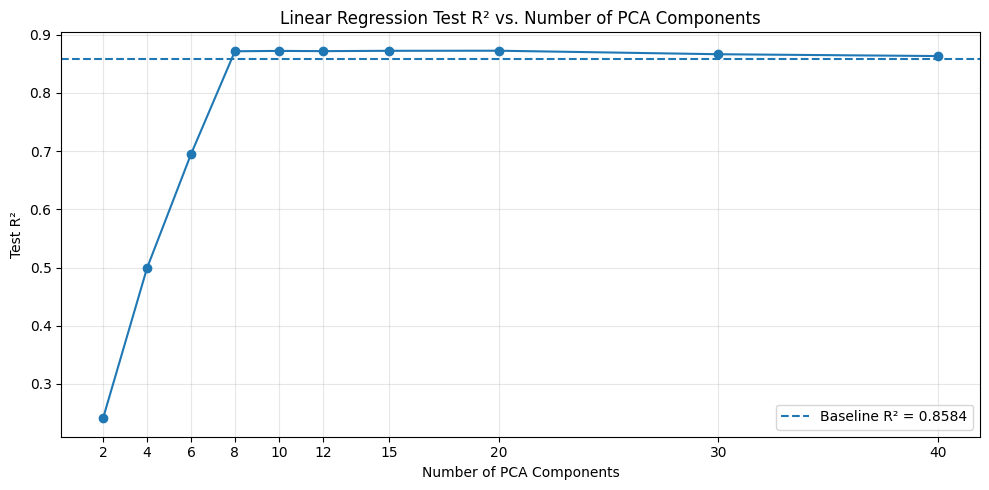

In [8]:
plt.figure(figsize=(10,5))
plt.plot(results_df["components"], results_df["test_r2"], marker="o")
plt.axhline(baseline_r2, linestyle="--",
            label=f"Baseline R² = {baseline_r2:.4f}")
plt.xlabel("Number of PCA Components")
plt.ylabel("Test R²")
plt.title("Linear Regression Test R² vs. Number of PCA Components")
plt.xticks(component_counts)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [9]:
acceptable = results_df[
    results_df["test_r2"] >= baseline_r2 - 0.01
].sort_values("components")

smallest_components = int(acceptable.iloc[0]["components"])
smallest_r2 = float(acceptable.iloc[0]["test_r2"])

print(f"Baseline R²: {baseline_r2:.6f}")
print(f"Smallest acceptable component count: {smallest_components}")
print(f"R² at selected count: {smallest_r2:.6f}")
print(f"Difference from baseline: {smallest_r2-baseline_r2:+.6f}")


Baseline R²: 0.858373
Smallest acceptable component count: 8
R² at selected count: 0.871584
Difference from baseline: +0.013211


### Component Selection

The smallest acceptable number is **8 components**.

- Baseline R²: **0.858373**
- R² at 8 components: **0.871584**
- Acceptance threshold: **0.848373**
- Difference from baseline: **+0.013211**

The visual scree-plot estimate (**~8**) and the empirical selection (**8**) agree.

## 4.4 — Explanation

The all-feature Linear Regression model achieved a test R² of 0.8584, while using only 8 PCA components increased the test R² to 0.8716. The scree plot showed an elbow around 8 components, and these 8 components explained 95% of the total variance, meaning most of the useful information in the 60 features could be captured in just 8 dimensions. This suggests that the original 60 features were highly correlated and contained substantial redundancy, rather than representing 60 independent sources of information. In other words, many of the features were likely measuring different aspects of a smaller number of underlying latent factors. PCA was therefore able to compress the data while retaining the important structure, and the slightly higher R² shows that removing redundant or noisy directions can even improve generalization.

## Optional Bonus - RandomForestRegressor

In [10]:
rf_baseline = RandomForestRegressor(
    n_estimators=200, random_state=42, n_jobs=-1
)
rf_baseline.fit(X_train_scaled, y_train)
rf_baseline_r2 = r2_score(y_test, rf_baseline.predict(X_test_scaled))

rf_results = []
for n in component_counts:
    pca_n = PCA(n_components=n)
    Xtr_n = pca_n.fit_transform(X_train_scaled)
    Xte_n = pca_n.transform(X_test_scaled)

    rf = RandomForestRegressor(
        n_estimators=200, random_state=42, n_jobs=-1
    )
    rf.fit(Xtr_n, y_train)
    rf_results.append({
        "components": n,
        "test_r2": r2_score(y_test, rf.predict(Xte_n))
    })

rf_results_df = pd.DataFrame(rf_results)
print(f"Random Forest baseline R²: {rf_baseline_r2:.6f}")
rf_results_df


Random Forest baseline R²: 0.796716


,components,test_r2
0,2,0.165454
1,4,0.415267
2,6,0.607331
3,8,0.742408
4,10,0.732798
5,12,0.723383
6,15,0.715123
7,20,0.701550
8,30,0.680936
9,40,0.662747


In [11]:
rf_acceptable = rf_results_df[
    rf_results_df["test_r2"] >= rf_baseline_r2 - 0.01
]

if len(rf_acceptable):
    print("Smallest RF component count meeting the ±0.01 rule:",
          int(rf_acceptable.iloc[0]["components"]))
else:
    print("None of the required component counts matched the RF baseline within 0.01.")


None of the required component counts matched the RF baseline within 0.01.


### Interpretation

For the supplied data, the Random Forest baseline is **0.796716**. None of the required PCA component counts matches that baseline within 0.01. This can happen because PCA rotates the original feature space into linear combinations, while tree-based models make splits along individual input dimensions. Linear Regression can benefit from decorrelation and compact latent directions, whereas a tree model may lose useful axis-aligned split structure after the PCA transformation.